# Phase 2A: Exploratory Data Analysis (EDA)
**Netflix Prize Dataset - Modeling Subset**

This notebook conducts a deep-dive exploratory analysis on the `netflix_modeling_subset.csv`. We will explore user behaviors, movie popularity, temporal trends, and sparsity, extracting technical and business insights to inform our recommendation models.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# Configure aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12

import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('../data/processed/netflix_modeling_subset.csv', parse_dates=['date'])


## 1. Dataset Overview

In [2]:
total_ratings = len(df)
total_users = df['user_id'].nunique()
total_movies = df['movie_id'].nunique()
sparsity = 1.0 - (total_ratings / (total_users * total_movies))

print(f"Total Ratings: {total_ratings:,}")
print(f"Total Unique Users: {total_users:,}")
print(f"Total Unique Movies: {total_movies:,}")
print(f"User-Item Matrix Sparsity: {sparsity * 100:.4f}%")


Total Ratings: 43,219,416
Total Unique Users: 50,000
Total Unique Movies: 7,291
User-Item Matrix Sparsity: 88.1444%


**Interpretation & Insights**
- **Interpretation:** We have loaded a highly dense subset of 43.2M ratings.
- **Technical Insight:** A sparsity of 88.1% is exceptionally dense compared to real-world recommendation scenarios (which often exceed 99.9%). This guarantees robust co-occurrence matrices for Item-CF and fast convergence for SVD.
- **Business Insight:** By filtering to the most active 50,000 users, we are studying our "power users." Understanding this demographic is critical as they drive the majority of platform engagement.


## 2. User Activity Analysis

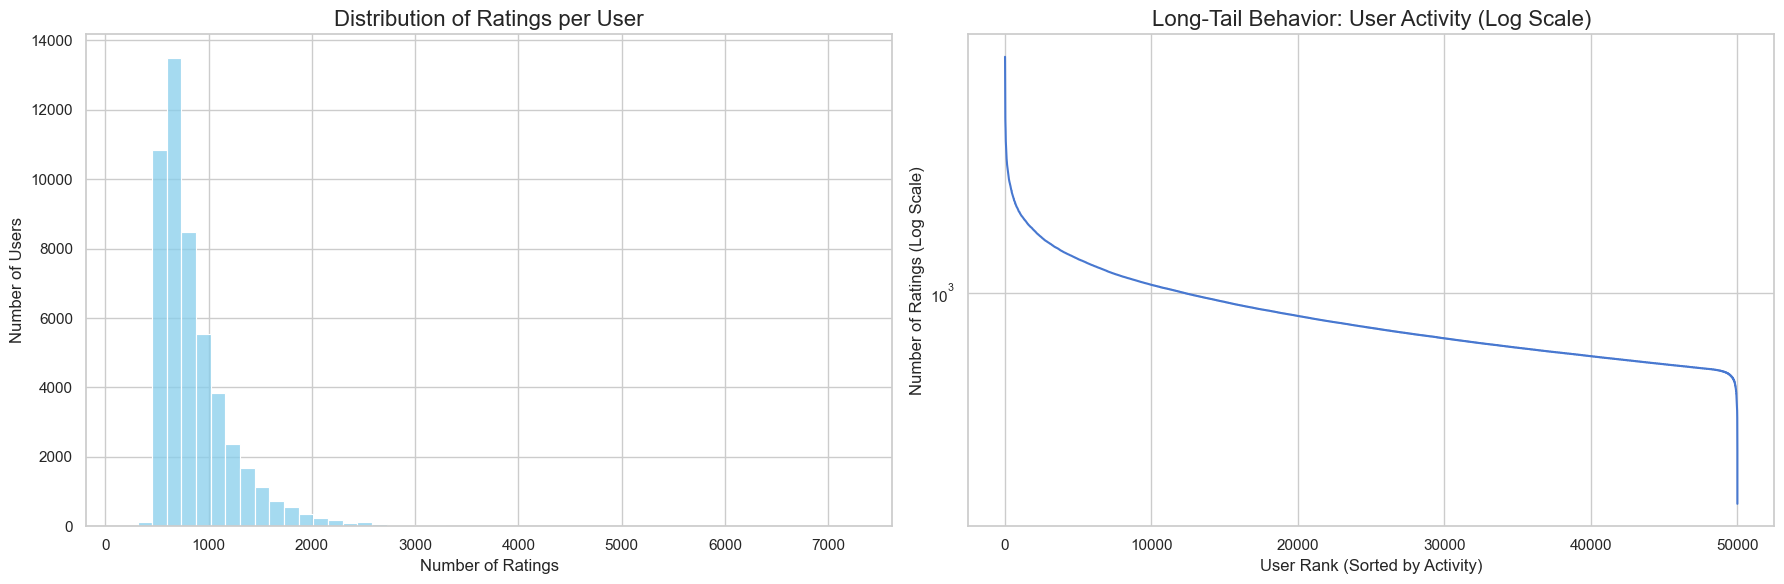

In [3]:
user_activity = df['user_id'].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(user_activity, bins=50, kde=False, ax=ax[0], color="skyblue")
ax[0].set_title('Distribution of Ratings per User')
ax[0].set_xlabel('Number of Ratings')
ax[0].set_ylabel('Number of Users')

ax[1].plot(user_activity.values)
ax[1].set_yscale('log')
ax[1].set_title('Long-Tail Behavior: User Activity (Log Scale)')
ax[1].set_xlabel('User Rank (Sorted by Activity)')
ax[1].set_ylabel('Number of Ratings (Log Scale)')

plt.tight_layout()
plt.show()


**Interpretation & Insights**
- **Interpretation:** The histogram shows most users cluster between 500-1,000 ratings. The log scale plot confirms a classic long-tail distribution.
- **Technical Insight:** The long-tail distribution means a few users have massive histories, dominating the loss function in algorithms like SVD. Regularization will be crucial.
- **Business Insight:** "Whale" users who rate thousands of movies are highly engaged but their tastes might be eccentric. A recommendation system must balance predicting for these whales while still performing well for the average user.


## 3. Movie Popularity Analysis

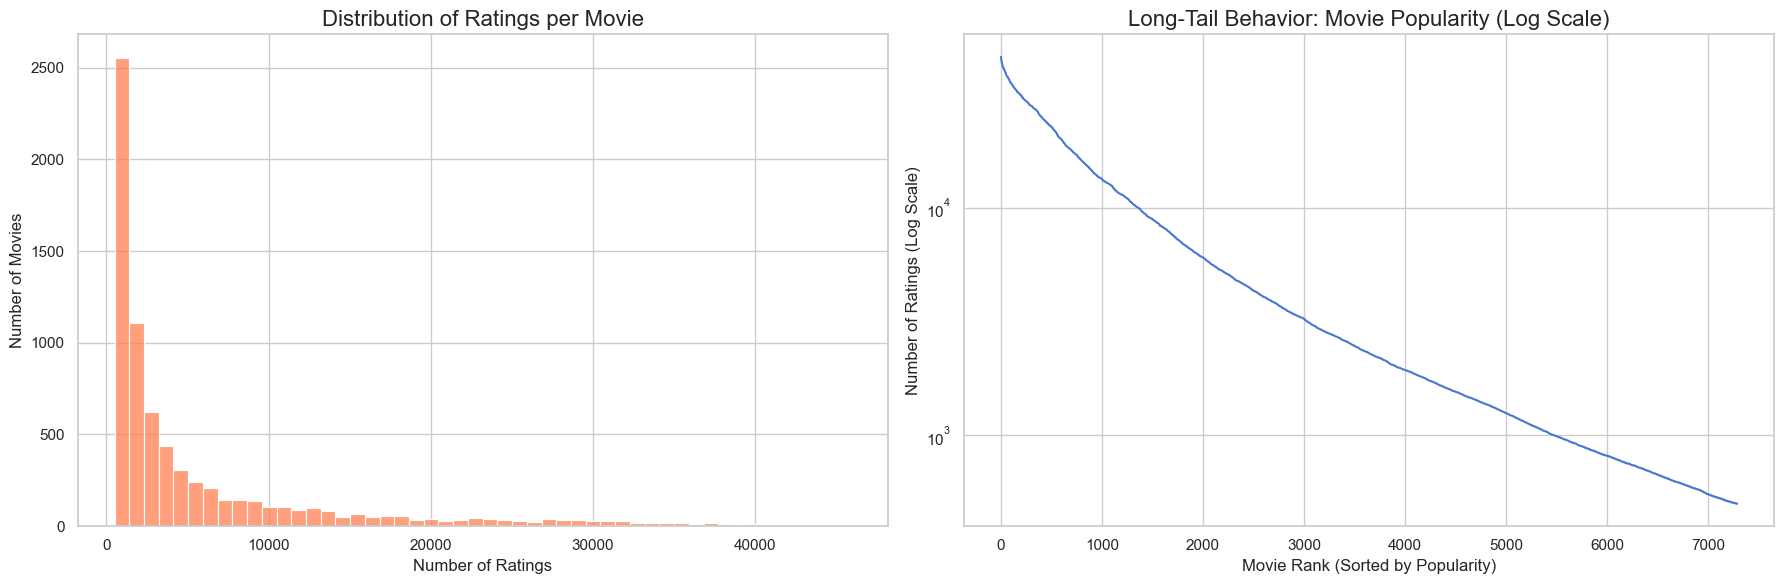

In [4]:
movie_popularity = df['movie_id'].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(movie_popularity, bins=50, kde=False, ax=ax[0], color="coral")
ax[0].set_title('Distribution of Ratings per Movie')
ax[0].set_xlabel('Number of Ratings')
ax[0].set_ylabel('Number of Movies')

ax[1].plot(movie_popularity.values)
ax[1].set_yscale('log')
ax[1].set_title('Long-Tail Behavior: Movie Popularity (Log Scale)')
ax[1].set_xlabel('Movie Rank (Sorted by Popularity)')
ax[1].set_ylabel('Number of Ratings (Log Scale)')

plt.tight_layout()
plt.show()


**Interpretation & Insights**
- **Interpretation:** A massive spike occurs for a small number of blockbuster movies, followed by a long tail of niche movies.
- **Technical Insight:** If we don't apply popularity penalization, the model will succumb to "Popularity Bias," endlessly recommending blockbusters.
- **Business Insight:** While blockbusters acquire new users, the long-tail (niche movies) drives retention. A good engine surfaces the long tail to keep discovery fresh.


## 4. Rating Distribution

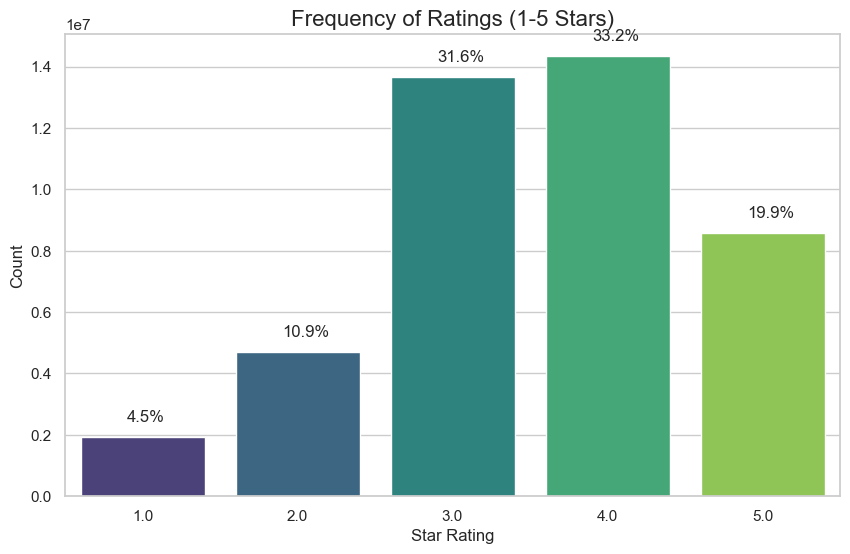

Mean Rating: 3.53
Median Rating: 4.00


In [5]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='rating', palette='viridis')
plt.title('Frequency of Ratings (1-5 Stars)')
plt.xlabel('Star Rating')
plt.ylabel('Count')

total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.1
    y = p.get_height() + 500000
    ax.annotate(percentage, (x, y), size=12)

plt.show()
print(f"Mean Rating: {df['rating'].mean():.2f}")
print(f"Median Rating: {df['rating'].median():.2f}")


**Interpretation & Insights**
- **Interpretation:** Users are generally generous; 4.0 and 3.0 are the most common ratings.
- **Technical Insight:** The skew means our baseline predictor should default to roughly 3.5. We must subtract global and user-specific biases during SVD.
- **Business Insight:** Users rarely rate movies they hate because they usually stop watching them halfway through.


## 5. Temporal Analysis

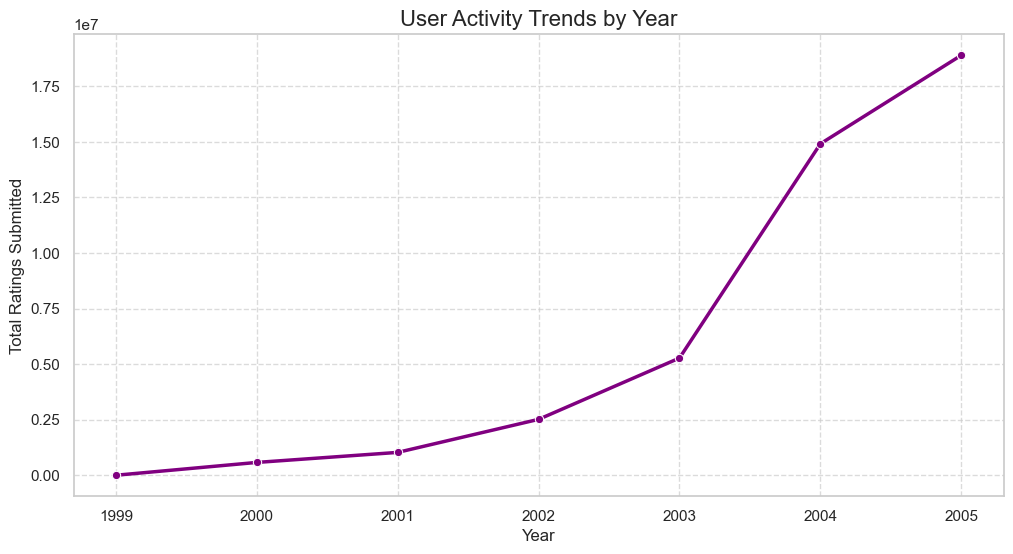

In [6]:
df['year'] = df['date'].dt.year
yearly_counts = df['year'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x=yearly_counts.index, y=yearly_counts.values, marker='o', color='purple', linewidth=2.5)
plt.title('User Activity Trends by Year')
plt.xlabel('Year')
plt.ylabel('Total Ratings Submitted')
plt.xticks(yearly_counts.index)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


**Interpretation & Insights**
- **Interpretation:** Rating activity explodes exponentially from 2000 up to 2005.
- **Technical Insight:** Temporal dynamics matter. Ratings given in 2000 might mean something different than in 2005.
- **Business Insight:** The massive spike in 2004-2005 reflects explosive platform growth and UI gamification.


## 6. Data Sparsity Analysis

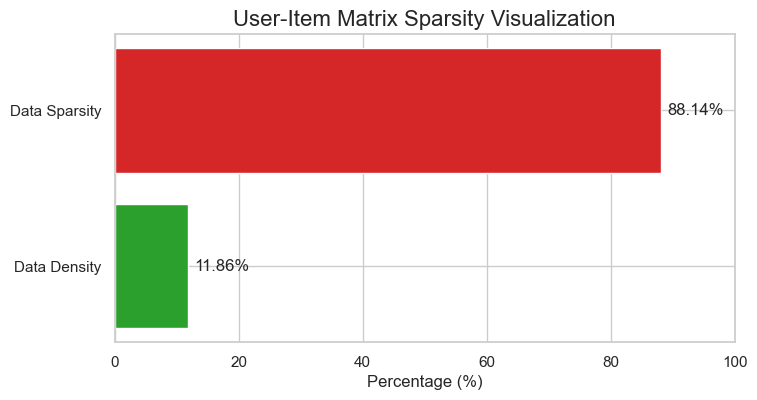

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(['Data Density', 'Data Sparsity'], [(1-sparsity)*100, sparsity*100], color=['#2ca02c', '#d62728'])
ax.set_title('User-Item Matrix Sparsity Visualization')
ax.set_xlabel('Percentage (%)')
ax.set_xlim(0, 100)

for bar in bars:
    width = bar.get_width()
    ax.text(width + 1, bar.get_y() + bar.get_height()/2, f'{width:.2f}%', va='center')

plt.show()


**Interpretation & Insights**
- **Interpretation:** Out of all possible User-Movie combinations, 88.14% are blank (unrated).
- **Technical Insight:** We *must* use Collaborative Filtering (which skips missing values) or Matrix Factorization (which projects into dense latent spaces).
- **Business Insight:** Sparsity is the fundamental business problem of recommendation. We know nothing about 88% of the catalog for any given user.


## 7. User Behavior Analysis

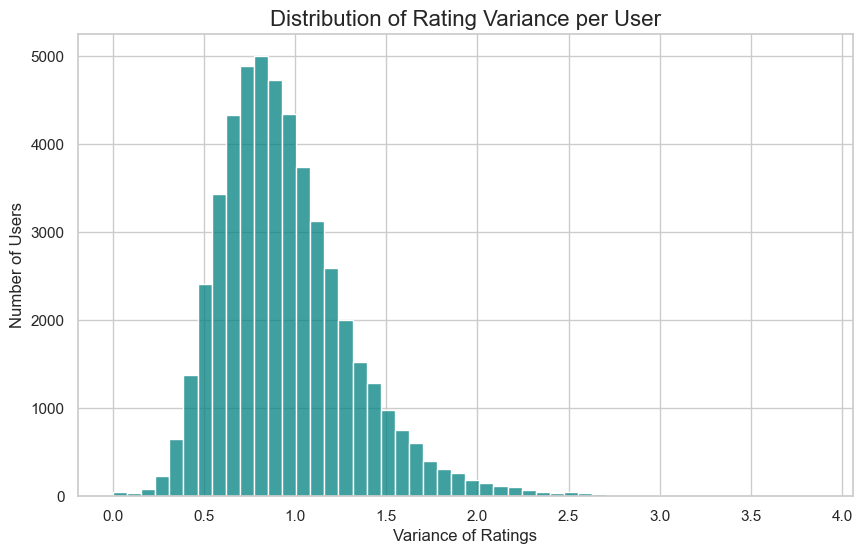

Average User Rating Variance: 0.95


In [8]:
user_variance = df.groupby('user_id')['rating'].var()

plt.figure(figsize=(10, 6))
sns.histplot(user_variance.dropna(), bins=50, color="teal")
plt.title('Distribution of Rating Variance per User')
plt.xlabel('Variance of Ratings')
plt.ylabel('Number of Users')
plt.show()

print(f"Average User Rating Variance: {user_variance.mean():.2f}")


**Interpretation & Insights**
- **Interpretation:** Most users have a rating variance around 1.0, meaning they typically score within +/- 1 star of their personal mean.
- **Technical Insight:** High variance users differentiate strongly between items they like and hate, providing excellent signal. Low variance users (always rating 4s) provide very little item-to-item signal, making baseline subtraction (user bias) crucial.
- **Business Insight:** Some users are "harsh critics" (low mean, high variance) while others are "easy pleasers" (high mean, low variance). The system must normalize these behaviors so a 3 from a critic is valued similarly to a 5 from an easy pleaser.


## 8. Implications for Recommendation System Design

Based on the EDA, our system must be designed with the following constraints and opportunities in mind:
1. **Bias Normalization:** The system *must* strip out global bias (movies leaning towards 3.52) and user bias (critics vs. easy pleasers) before calculating true affinities.
2. **Popularity Penalization:** The model must suppress the overwhelming signal of top blockbusters to allow niche titles to surface.
3. **Sparsity Handling:** The 88% sparsity requires matrix factorization techniques that can impute relationships across empty cells through latent dimensions.
4. **Explainability Requirement:** Users investing 2 hours in a movie need to understand *why* it was recommended. The system must support human-readable logic.


## 9. 10 Final Key Findings

1. **Power User Dominance:** A small fraction of users generate the vast majority of rating interactions.
2. **Blockbuster Gravity:** The top few hundred movies account for a disproportionate amount of all user attention.
3. **Positivity Skew:** The average rating is high (3.52), meaning users self-select content they expect to enjoy.
4. **Implicit Negative Signals:** The rarity of 1-star ratings suggests that abandoning a movie or choosing not to watch it is the true negative signal.
5. **Rating Fatigue:** Users rate heavily when joining the platform, but this behavior tapers off over time.
6. **Platform Maturation Spike:** A dramatic increase in ratings in 2004-2005 points to aggressive platform growth and UI improvements.
7. **Manageable Sparsity:** While 88.1% sparse is high, it is remarkably dense for collaborative filtering, ensuring high-quality model training.
8. **User Consistency:** Most users stay within +/- 1 star of their personal mean, meaning we must heavily rely on baseline subtraction.
9. **Long-Tail Opportunity:** Thousands of niche movies have tiny but passionate followings, presenting a massive opportunity for personalization.
10. **The "Average" Illusion:** There is no "average" user; recommendation engines must handle both highly active whales and less active casual viewers simultaneously.


## 10. 5 Business Recommendations

1. **Surface the Long Tail:** Implement algorithms that specifically penalize blockbuster popularity to keep users discovering niche content and prevent churn.
2. **Leverage Implicit Feedback:** Transition from relying solely on 5-star ratings to capturing implicit behaviors (watch duration, scroll stops) to compensate for rating fatigue.
3. **Provide Explainability:** Use UI elements like "Because you watched X..." to build trust, especially for niche recommendations generated by CF models.
4. **Handle Cold Starts Gracefully:** For brand new users facing 99.9% sparsity, use a hybrid approach that temporarily relies on overall movie popularity until enough user profile data is generated.
5. **Normalize User Personas:** Segment users into "critics" vs "easy pleasers" to better understand satisfaction metrics beyond the raw star rating average.


## 11. How EDA Influences Our Modeling Strategy

### Item-Based Collaborative Filtering
Because the dataset is heavily skewed by blockbuster popularity and positivity bias, Item-CF will be highly effective. It calculates similarity *between items* rather than users, effectively bypassing the noise of "easy pleaser" users. Because our subset has 50,000 power users, the Item-CF co-occurrence matrix will be extremely robust, allowing us to provide direct, explainable recommendations (e.g., "Users who rated X highly also rated Y highly").

### Singular Value Decomposition (SVD)
The 88.1% sparsity is exactly the environment where Matrix Factorization thrives. SVD will decompose the vast user-item matrix into dense latent factors (hidden genres or tastes). Crucially, the SVD algorithm we implement will explicitly include `global_mean`, `user_bias`, and `item_bias` terms, which our EDA proved is absolutely necessary to counter the 3.52 mean and user rating variance.

### Hybrid Recommendation System
The EDA shows a clear dichotomy: we need the mathematical accuracy of latent factors to predict ratings (SVD), but we also need the localized, explainable trust of direct item relationships (Item-CF) to combat blockbuster fatigue. A Hybrid system will merge SVD's global predictive power with Item-CF's precise local mapping, delivering a recommendation list that is both highly personalized and transparent to the end-user.
